In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("E:\electricity_random_dataset_200.csv")
df.head()

,Customer_ID,Units_Consumed,Rate_per_Unit,Electricity_Bill
0,CUST001,1091,9.0,9850.71
1,CUST002,265,6.0,1565.06
2,CUST003,1126,9.0,10154.82
3,CUST004,935,9.0,8369.23
4,CUST005,745,7.5,5619.57


In [4]:
df.isnull().sum()

Customer_ID         0
Units_Consumed      0
Rate_per_Unit       0
Electricity_Bill    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       200 non-null    object 
 1   Units_Consumed    200 non-null    int64  
 2   Rate_per_Unit     200 non-null    float64
 3   Electricity_Bill  200 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 6.4+ KB


In [6]:
df.describe()

,Units_Consumed,Rate_per_Unit,Electricity_Bill
count,200.000000,200.000000,200.000000
mean,630.870000,7.245000,5068.786600
std,332.141995,1.563553,3295.521695
min,45.000000,4.500000,158.030000
25%,345.250000,6.000000,2060.482500
50%,642.000000,7.500000,4820.915000
75%,920.750000,9.000000,8328.402500
max,1194.000000,9.000000,10766.110000


In [8]:
new_df=df[['Units_Consumed','Electricity_Bill']]
new_df.head()

,Units_Consumed,Electricity_Bill
0,1091,9850.71
1,265,1565.06
2,1126,10154.82
3,935,8369.23
4,745,5619.57


[]

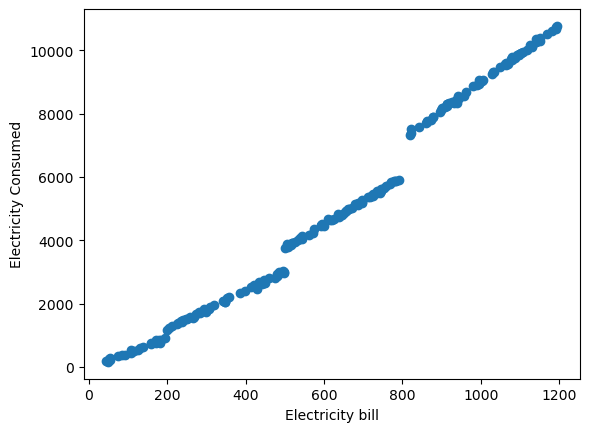

In [14]:
plt.scatter(new_df['Units_Consumed'],new_df['Electricity_Bill'])
plt.xlabel('Electricity bill')
plt.ylabel('Electricity Consumed')
plt.plot()


In [16]:
# spliting the data
X=new_df.iloc[:,:-1].values
y=new_df.iloc[:,-1].values

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred=lr.predict(X_test)
y_pred

array([ 1732.93913626,  1594.09343803,  6314.8471778 ,  4668.5338988 ,
        7713.22170995, 10202.52672819,  1703.18648664,   -52.21984096,
        7802.47965881,  -756.36588197,  3746.20176057,   741.18414892,
        -468.75693564,  1177.55634335, 10113.26877933,    86.62585727,
        5521.44318792,  9528.1333368 ,  1861.86728462,  6185.91902944,
       10609.146273  ,  5719.79418539,  1604.01098791,   384.15235347,
        4688.36899855,  4906.55509577,  7911.57270742,   572.58580107,
        3557.76831298,  1266.81429221,  6523.11572514,  4668.5338988 ,
        4995.81304463,  7733.0568097 ,  -359.66388704,  -706.77813261,
        5600.78358691,  7861.98495806,  6909.9001702 ,  8655.38894793,
          46.95565778,  3637.10871196,  8655.38894793,  9319.86478945,
        8129.75880464,  3706.53156108,  1167.63879348,  4847.04979653,
        8506.62569983,  3220.57161728,  3111.47856867,  9776.07208363,
        7495.03561274,  1068.46329474,  9498.38068718,  9676.8965849 ,
      

In [27]:
y_test

array([ 1767.86,  1719.3 ,  5704.81,  4459.69,  8122.8 , 10297.77,
        1836.2 ,   510.84,  8196.87,   189.71,  2977.96,   908.18,
         356.44,  1484.58, 10263.56,   597.21,  5131.41,  9738.66,
        1878.93,  5565.01, 10736.18,  5222.6 ,  1701.82,   712.05,
        4496.78,  4646.36,  8327.3 ,   838.46,  2855.72,  1505.39,
        5872.52,  4481.55,  4684.58,  8187.24,   384.93,   158.03,
        5115.67,  8287.73,  7323.78,  8932.94,   543.54,  2972.89,
        9047.13,  9549.7 ,  8551.05,  3016.21,  1422.13,  4662.48,
        8860.29,  2740.68,  2682.42,  9935.21,  7894.86,  1378.25,
        9701.77,  9837.38,  2622.91,  5546.44,  5768.03,  3902.21,
        1554.78,  3758.07,  4920.51,  8499.11,  4214.15,   847.  ])

In [30]:
c=lr.coef_

In [31]:
i=lr.intercept_

In [33]:
265*c+i

array([1425.49509018])

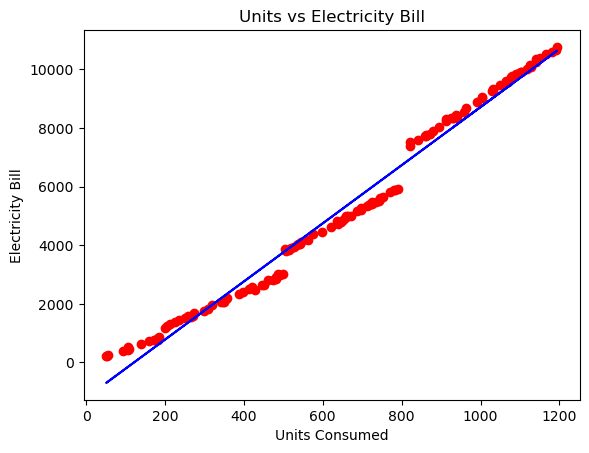

In [48]:
plt.scatter(X_train, y_train, color='red')      # Actual data
plt.plot(X_train, lr.predict(X_train), color='blue')   # Best fit line

plt.title("Units vs Electricity Bill")
plt.xlabel("Units Consumed")
plt.ylabel("Electricity Bill")
plt.show()

In [49]:
def predict_bill(units):
    
    prediction = lr.predict([[units]])
    
    return f"Estimated Electricity Bill: {prediction[0]:.2f}"

In [51]:
import gradio as gr

app = gr.Interface(
    
    fn=predict_bill,
    
    inputs=gr.Number(label="Enter Units Consumed"),
    
    outputs=gr.Textbox(label="$ Predicted Bill"),
    
    title="Electricity Bill Predictor",
    
    description="Enter electricity units to predict the bill"
)

app.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [53]:
from gradio_client import Client

client = Client("http://127.0.0.1:7861")
result = client.predict(
	units=3,
	api_name="/predict_bill",
)
print(result)

Loaded as API: http://127.0.0.1:7861/
Estimated Electricity Bill: -1172.90
Created dataset file at: .gradio\flagged\dataset1.csv


# Multiple Linear Regression

In [1]:
import numpy as np
from sklearn.datasets import load_diabetes

In [4]:
X,y=load_diabetes(return_X_y=True)
X.shape
y.shape

(442,)

In [7]:
# linear regression using scikit -learn 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [8]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
reg=LinearRegression()

In [11]:
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred=reg.predict(X_test)

In [14]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.4399338661568968

In [15]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [16]:
reg.intercept_

np.float64(151.88331005254167)

# making our own linear regression class

In [17]:
class MeraLr:
    def __init__(self):
        self.coef_=None
        self.intercept_=None
    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)

        # calculate the coeffs
        batas=np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_=batas[0]
        self.coef_=batas[1:]

    def predict(self,X_test):
        y_pred=np.dot(X_test,self.coef_)+self.intercept_
        return y_pred

In [18]:
lr=MeraLr()

In [19]:
lr.fit(X_train,y_train)

In [20]:
X_train.shape

(353, 10)

In [21]:
np.insert(X_train,0,1,axis=1).shape

(353, 11)

In [23]:
y_pred=lr.predict(X_test)

In [24]:
r2_score(y_test,y_pred)

0.4399338661568968

In [25]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [26]:
lr.intercept_

np.float64(151.8833100525417)

In [ ]:
# multiple linear regression

In [27]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [31]:
X,y=make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)


In [32]:
df=pd.DataFrame({"feature1":X[:,0],'feature2':X[:,1],'target':y})

In [33]:
df.shape

(100, 3)

In [34]:
df.head()

,feature1,feature2,target
0,-1.220450,-1.604474,-130.967048
1,2.830596,1.332890,171.013671
2,0.068799,-0.482102,-13.474416
3,-0.505917,-1.192686,-112.642161
4,0.163231,2.062930,72.372003


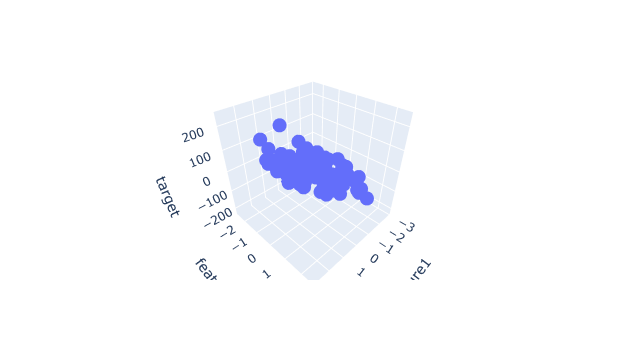

In [35]:
fig=px.scatter_3d(df,x='feature1',y='feature2',z='target')
fig.show()

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=3)

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
lr=LinearRegression()

In [40]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_pred=lr.predict(X_test)

In [42]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 49.63420895432263
MSE 3549.5346676778054
R2 score 0.678403172172203


In [45]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

z_final = lr.predict(X).reshape(10,10)

z = z_final

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

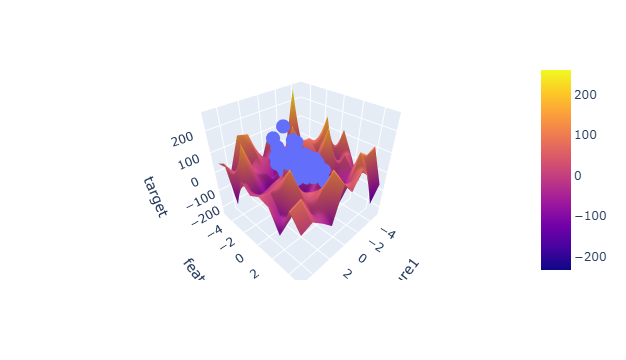

In [46]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [47]:
lr.coef_

array([76.24697359, 38.62809453])

In [48]:
lr.intercept_

np.float64(-6.655973098077039)

In [49]:
def predict_bill(featur1,feature2):
    
    prediction = lr.predict([[featur1,feature2]])
    
    return f"Estimated Electricity Bill: {prediction[0]:.2f}"

In [52]:
import gradio as gr

app = gr.Interface(
    
    fn=predict_bill,
    
    inputs=gr.Number(label="Enter Units Consumed"),
    
    outputs=gr.Textbox(label="$ Predicted Bill"),
    
    title="Electricity Bill Predictor",
    
    description="Enter electricity units to predict the bill"
)

app.launch()

SyntaxError: keyword argument repeated: label (600431705.py, line 7)